<a href="https://colab.research.google.com/github/spdb9876/loan-default-prediction/blob/main/01_data_wrangling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import os
from google.colab import userdata

# Step 1: Install the Kaggle API client
!pip install kaggle --quiet

# Retrieve the Kaggle API key from Colab secrets
# retrive from enviornment variable
kaggle_json_content = userdata.get('KAGGLE_JSON')

# Create the ~/.kaggle directory if it doesn't exist
os.makedirs('/root/.kaggle', exist_ok=True)

# Write the content to kaggle.json
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_json_content)

# Set correct permissions (important for security)
os.chmod('/root/.kaggle/kaggle.json', 600)

print("Kaggle API key setup complete using Colab Secrets.")

# Step 3: Download the specified file from the competition
competition_name = "home-credit-default-risk"
# Correcting the file name: often Kaggle uses underscores instead of periods.
file_name = "application_train.csv"
output_directory = "."

print(f"Attempting to download {file_name} from {competition_name}...")
!kaggle competitions download -c {competition_name} -f {file_name} -p {output_directory}


print(f"Download command executed. Check the directory '{output_directory}' for the file.")

Kaggle API key setup complete using Colab Secrets.
Attempting to download application_train.csv from home-credit-default-risk...
application_train.csv.zip: Skipping, found more recently modified local copy (use --force to force download)
Download command executed. Check the directory '.' for the file.


In [22]:
import pandas as pd
import zipfile
import os

# Unzip the downloaded file
zip_file_name = f"./{file_name}.zip"
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(output_directory)
print(f"Extracted {file_name} from {zip_file_name} to {output_directory}/")

# List files in the directory to confirm extraction
!ls -lh {output_directory}

Extracted application_train.csv from ./application_train.csv.zip to ./
total 226M
-rw-r--r-- 1 root root  26M Apr  5 01:36 application_test.csv
-rw-r--r-- 1 root root 5.9M Dec 11  2019 application_test.csv.zip
-rw-r--r-- 1 root root 159M Apr  5 01:42 application_train.csv
-rw-r--r-- 1 root root  37M Dec 11  2019 application_train.csv.zip
drwxr-xr-x 1 root root 4.0K Apr  2 13:31 sample_data


In [23]:


# Define the zip file name and the expected extracted file path
zip_file_path = os.path.join(output_directory, f"{file_name}.zip")
extracted_csv_path = os.path.join(output_directory, file_name)

# Check if the zip file exists and the CSV file has not been extracted yet
if os.path.exists(zip_file_path) and not os.path.exists(extracted_csv_path):
    print(f"Unzipping {zip_file_path} to {output_directory}...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(output_directory)
    print(f"Extracted {file_name} from {zip_file_path}.")
elif os.path.exists(extracted_csv_path):
    print(f"File {file_name} already extracted at {extracted_csv_path}.")
else:
    print(f"Warning: Neither zip file {zip_file_path} nor extracted CSV {extracted_csv_path} found. Attempting to proceed with reading CSV.")

# Load the extracted CSV file into a pandas DataFrame
df = pd.read_csv(extracted_csv_path)

# Display the first 5 rows of the DataFrame
print(f"\nDisplaying the first 5 rows of {file_name}:")
display(df.head())

File application_train.csv already extracted at ./application_train.csv.

Displaying the first 5 rows of application_train.csv:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0




```
# This is formatted as code
```



In [24]:
anomaly_count = df[df['DAYS_EMPLOYED'] == 365243]
print(f"Number of anomalies in 'DAYS_EMPLOYED': {len(anomaly_count)}")
# print sample anomaly data
display(anomaly_count.head())

Number of anomalies in 'DAYS_EMPLOYED': 55374


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
8,100011,0,Cash loans,F,N,Y,0,112500.000,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
11,100015,0,Cash loans,F,N,Y,0,38419.155,148365.0,10678.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
23,100027,0,Cash loans,F,N,Y,0,83250.000,239850.0,23850.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
38,100045,0,Cash loans,F,N,Y,0,99000.000,247275.0,17338.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
43,100050,0,Cash loans,F,N,Y,0,108000.000,746280.0,42970.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0


In [25]:
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100


# Create a DataFrame for missing values
missing_info = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percentage
})

# Filter out columns with no missing values and sort by percentage
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("\nMissing Data Analysis for application_train.csv:")
display(missing_info)


Missing Data Analysis for application_train.csv:


,Missing Count,Missing Percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
...,...,...
EXT_SOURCE_2,660,0.214626
AMT_GOODS_PRICE,278,0.090403
AMT_ANNUITY,12,0.003902
CNT_FAM_MEMBERS,2,0.000650


### Strategies for Handling Missing Values

When dealing with missing values, the strategy often depends on the percentage of missing data and the nature of the column (numerical or categorical).

1.  **Drop Columns with High Missing Percentage**: For columns with a very high percentage of missing values (e.g., over 60-70%), it's often best to drop them as imputing them might introduce too much noise or bias. These columns might not provide much predictive power.
    *   **Example from `missing_info`**: `COMMONAREA_MEDI`, `COMMONAREA_MODE`, `COMMONAREA_AVG`, `NONLIVINGAPARTMENTS_MODE`, etc., all have around 70% missing data.

2.  **Imputation for Numerical Columns (Moderate Missing Percentage)**:
    *   **Median/Mean Imputation**: For numerical features with a moderate amount of missing data, imputing with the median (less sensitive to outliers) or mean can be effective.
    *   **Example**: Columns like `AMT_REQ_CREDIT_BUREAU_DAY` (around 13.5% missing) or `EXT_SOURCE_1` (around 56% missing) could be candidates for this, depending on domain knowledge and further analysis.

3.  **Imputation for Categorical Columns (Moderate Missing Percentage)**:
    *   **Mode Imputation**: For categorical features, imputing with the mode (most frequent category) is a common practice.
    *   **Treat as a Separate Category**: Sometimes, the fact that a value is missing can itself be informative. In such cases, you can treat missing values as a new, distinct category.

4.  **Drop Rows (Low Missing Percentage)**: If a column has a very small percentage of missing values (e.g., less than 5%) and dropping these few rows won't significantly reduce your dataset size, it can be a simple and effective strategy, especially if imputation is complex or inappropriate for the feature.
    *   **Example**: `EXT_SOURCE_2` has only 0.21% missing data, making it a candidate for row dropping if `SK_ID_CURR` is the unique identifier for rows and imputation is not preferred.

---

### Applying Missing Value Strategies

Let's apply some of these strategies. We'll start by dropping columns with more than 60% missing values.

In [26]:
# Get columns with more than 60% missing values
threshold = 60
columns_to_drop = missing_info[missing_info['Missing Percentage'] > threshold].index.tolist()

print(f"Dropping {len(columns_to_drop)} columns with more than {threshold}% missing values:")
print(columns_to_drop)

# Drop these columns from the DataFrame
df_cleaned = df.drop(columns=columns_to_drop)

print(f"DataFrame shape after dropping columns: {df_cleaned.shape}")


Dropping 17 columns with more than 60% missing values:
['COMMONAREA_MEDI', 'COMMONAREA_MODE', 'COMMONAREA_AVG', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_AVG', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE', 'FLOORSMIN_MEDI', 'FLOORSMIN_MODE', 'FLOORSMIN_AVG', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_AVG', 'OWN_CAR_AGE']
DataFrame shape after dropping columns: (307511, 105)


Next, let's impute remaining numerical columns with their median and categorical columns with their mode. We'll recalculate missing values for the `df_cleaned` DataFrame first.

In [27]:
# Recalculate missing info for the cleaned DataFrame
missing_data_cleaned = df_cleaned.isnull().sum()
missing_percentage_cleaned = (missing_data_cleaned / len(df_cleaned)) * 100

missing_info_cleaned = pd.DataFrame({
    'Missing Count': missing_data_cleaned,
    'Missing Percentage': missing_percentage_cleaned
})

missing_info_cleaned = missing_info_cleaned[missing_info_cleaned['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("\nMissing Data Analysis for df_cleaned (after dropping high-missing columns):")
display(missing_info_cleaned)

# Identify numerical and categorical columns with missing values for imputation
numerical_cols_with_missing = df_cleaned[missing_info_cleaned.index].select_dtypes(include=['int64', 'float64']).columns
categorical_cols_with_missing = df_cleaned[missing_info_cleaned.index].select_dtypes(include=['object', 'category']).columns

# Impute numerical columns with median
for col in numerical_cols_with_missing:
    if df_cleaned[col].isnull().any():
        median_val = df_cleaned[col].median()
        df_cleaned[col].fillna(median_val, inplace=True)
        print(f"Imputed numerical column '{col}' with median: {median_val}")

# Impute categorical columns with mode
for col in categorical_cols_with_missing:
    if df_cleaned[col].isnull().any():
        mode_val = df_cleaned[col].mode()[0] # .mode() can return multiple values, take the first
        df_cleaned[col].fillna(mode_val, inplace=True)
        print(f"Imputed categorical column '{col}' with mode: {mode_val}")

print("\nMissing value imputation complete. Verifying no missing values remain:")
print(df_cleaned.isnull().sum().sum()) # Should be 0 if all missing values are handled



Missing Data Analysis for df_cleaned (after dropping high-missing columns):


,Missing Count,Missing Percentage
LANDAREA_AVG,182590,59.376738
LANDAREA_MODE,182590,59.376738
LANDAREA_MEDI,182590,59.376738
BASEMENTAREA_MEDI,179943,58.515956
BASEMENTAREA_MODE,179943,58.515956
BASEMENTAREA_AVG,179943,58.515956
EXT_SOURCE_1,173378,56.381073
NONLIVINGAREA_AVG,169682,55.179164
NONLIVINGAREA_MEDI,169682,55.179164
NONLIVINGAREA_MODE,169682,55.179164


/tmp/ipykernel_1700/1260736512.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[col].fillna(median_val, inplace=True)


Imputed numerical column 'LANDAREA_AVG' with median: 0.0481
Imputed numerical column 'LANDAREA_MODE' with median: 0.0458
Imputed numerical column 'LANDAREA_MEDI' with median: 0.0487
Imputed numerical column 'BASEMENTAREA_MEDI' with median: 0.0758
Imputed numerical column 'BASEMENTAREA_MODE' with median: 0.0746
Imputed numerical column 'BASEMENTAREA_AVG' with median: 0.0763
Imputed numerical column 'EXT_SOURCE_1' with median: 0.5059979305057544
Imputed numerical column 'NONLIVINGAREA_AVG' with median: 0.0036
Imputed numerical column 'NONLIVINGAREA_MEDI' with median: 0.0031
Imputed numerical column 'NONLIVINGAREA_MODE' with median: 0.0011
Imputed numerical column 'ELEVATORS_MEDI' with median: 0.0
Imputed numerical column 'ELEVATORS_MODE' with median: 0.0
Imputed numerical column 'ELEVATORS_AVG' with median: 0.0
Imputed numerical column 'APARTMENTS_AVG' with median: 0.0876
Imputed numerical column 'APARTMENTS_MODE' with median: 0.084
Imputed numerical column 'APARTMENTS_MEDI' with median:

/tmp/ipykernel_1700/1260736512.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[col].fillna(mode_val, inplace=True)


Imputed categorical column 'HOUSETYPE_MODE' with mode: block of flats
Imputed categorical column 'EMERGENCYSTATE_MODE' with mode: No
Imputed categorical column 'OCCUPATION_TYPE' with mode: Laborers
Imputed categorical column 'NAME_TYPE_SUITE' with mode: Unaccompanied

Missing value imputation complete. Verifying no missing values remain:
0


In [28]:
print("Total missing values remaining in df_cleaned:", df_cleaned.isnull().sum().sum())

Total missing values remaining in df_cleaned: 0


In [29]:
print("Checking 'DAYS_EMPLOYED' value counts in df_cleaned BEFORE anomaly handling:")
display(df_cleaned['DAYS_EMPLOYED'].value_counts().head())
print(f"Count of 365243 in 'DAYS_EMPLOYED': {df_cleaned['DAYS_EMPLOYED'].isin([365243]).sum()}")

Checking 'DAYS_EMPLOYED' value counts in df_cleaned BEFORE anomaly handling:


,count
DAYS_EMPLOYED,
365243,55374
-200,156
-224,152
-230,151
-199,151


Count of 365243 in 'DAYS_EMPLOYED': 55374


In [30]:
print("\n--- Outlier Handling ---\n")

# --- Specific Anomaly Handling for DAYS_EMPLOYED ---
# In this dataset, a common anomaly in 'DAYS_EMPLOYED' is the value 365243,
# which typically signifies missing or erroneous age data (e.g., 1000 years old).
# We will replace this specific "abnormally high" value with NaN.
print("Checking for and handling specific 'DAYS_EMPLOYED' anomaly (value = 365243)...")
anomaly_count = df_cleaned[df_cleaned['DAYS_EMPLOYED'] == 365243] # Corrected condition to match the explanation
print(f"Number of anomalies in 'DAYS_EMPLOYED': {len(anomaly_count)}")
# print sample anomaly data
display(anomaly_count.head())

if len(anomaly_count) > 0:
    print(f"Found {len(anomaly_count)} anomalies in 'DAYS_EMPLOYED'.") # Corrected print statement
    # FIX: Correctly assign result of replace; remove inplace=True if assigning
    df_cleaned['DAYS_EMPLOYED'] = df_cleaned['DAYS_EMPLOYED'].replace({365243: float('nan')})
    print(f"Replaced {len(anomaly_count)} anomalous 'DAYS_EMPLOYED' values (365243) with NaN.") # Corrected print statement
else:
    print("No specific 'DAYS_EMPLOYED' anomaly (365243) found.")

# FIX: Correct arguments for clip function
df_cleaned['AMT_INCOME_TOTAL'] = df_cleaned['AMT_INCOME_TOTAL'].clip(lower=0, upper=1e6)

# --- General Outlier Capping ---
# Select only numerical columns for outlier detection
numerical_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns

# Exclude 'SK_ID_CURR' and 'TARGET' as they are identifiers/target variable
numerical_cols = numerical_cols.drop(['SK_ID_CURR', 'TARGET'], errors='ignore')

print(f"\nApplying general outlier capping to {len(numerical_cols)} numerical columns (excluding 'DAYS_BIRTH' if already handled)...")

for col in numerical_cols:
    # We'll skip 'DAYS_Employed' if it has NaNs (from previous anomaly handling) or if we want specific treatment for it
    # The previous anomaly handling replaces 365243 with NaN. Now, we might want to impute these NaNs if they exist.
    if col == 'DAYS_EMPLOYED':
        # Re-impute 'DAYS_Employed' NaNs with median after anomaly detection
        if df_cleaned['DAYS_EMPLOYED'].isnull().any():
            median_birth = df_cleaned['DAYS_EMPLOYED'].median()
            df_cleaned['DAYS_EMPLOYED'].fillna(median_birth, inplace=True)
            print(f"Imputed NaNs in 'DAYS_EMPLOYED' with median: {median_birth}")
        continue # Skip general capping for DAYS_Employed as it was specifically treated

    Q1 = df_cleaned[col].quantile(0.01)
    Q3 = df_cleaned[col].quantile(0.99)

    # Using the IQR method for capping as discussed earlier
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned[col] = df_cleaned[col].clip(lower=lower_bound, upper=upper_bound)

print("Outlier capping complete for numerical columns.")

# Display some descriptive statistics to show the effect of capping
print("\nDescriptive statistics for a few capped numerical columns (after outlier handling):")
display(df_cleaned[numerical_cols].sample(5).describe())


--- Outlier Handling ---

Checking for and handling specific 'DAYS_EMPLOYED' anomaly (value = 365243)...
Number of anomalies in 'DAYS_EMPLOYED': 55374


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
8,100011,0,Cash loans,F,N,Y,0,112500.000,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
11,100015,0,Cash loans,F,N,Y,0,38419.155,148365.0,10678.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
23,100027,0,Cash loans,F,N,Y,0,83250.000,239850.0,23850.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
38,100045,0,Cash loans,F,N,Y,0,99000.000,247275.0,17338.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
43,100050,0,Cash loans,F,N,Y,0,108000.000,746280.0,42970.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0


Found 55374 anomalies in 'DAYS_EMPLOYED'.
Replaced 55374 anomalous 'DAYS_EMPLOYED' values (365243) with NaN.

Applying general outlier capping to 88 numerical columns (excluding 'DAYS_BIRTH' if already handled)...


/tmp/ipykernel_1700/251945315.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['DAYS_EMPLOYED'].fillna(median_birth, inplace=True)


Imputed NaNs in 'DAYS_EMPLOYED' with median: -1648.0
Outlier capping complete for numerical columns.

Descriptive statistics for a few capped numerical columns (after outlier handling):


,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,5.0,5.000000,5.000000e+00,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.000000,5.000000
mean,0.0,185400.000000,6.783192e+05,28578.60000,629100.000000,0.014910,-19008.800000,-1369.400000,-4671.800000,-3539.400000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.200000,1.400000
std,0.0,75259.052612,3.115421e+05,12060.98828,262323.369146,0.009535,5377.438954,622.968539,4898.151457,1654.257175,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.447214,1.140175
min,0.0,112500.000000,3.240000e+05,12213.00000,324000.000000,0.004960,-23682.000000,-1648.000000,-12465.000000,-5456.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
25%,0.0,135000.000000,4.500000e+05,23139.00000,450000.000000,0.007305,-22362.000000,-1648.000000,-5283.000000,-4183.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000
50%,0.0,157500.000000,6.393960e+05,30888.00000,571500.000000,0.014520,-21203.000000,-1648.000000,-4598.000000,-4032.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000
75%,0.0,225000.000000,9.000000e+05,31653.00000,900000.000000,0.019101,-17472.000000,-1648.000000,-785.000000,-3002.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,2.000000
max,0.0,297000.000000,1.078200e+06,45000.00000,900000.000000,0.028663,-10325.000000,-255.000000,-228.000000,-1024.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,3.000000


In [31]:

# Feature engineering

# Create new features
# Family-related features
df_cleaned['CHILDREN_RATIO'] = df_cleaned['CNT_CHILDREN'] / df_cleaned['CNT_FAM_MEMBERS']

# Financial ratios
df_cleaned['ANNUITY_INCOME_RATIO'] = df_cleaned['AMT_ANNUITY'] / df_cleaned['AMT_INCOME_TOTAL']
df_cleaned['CREDIT_INCOME_RATIO'] = df_cleaned['AMT_CREDIT'] / df_cleaned['AMT_INCOME_TOTAL']
df_cleaned['CREDIT_GOODS_RATIO'] = df_cleaned['AMT_CREDIT'] / df_cleaned['AMT_GOODS_PRICE']

print("New feature columns added successfully!")
print("Displaying the first 5 rows with new features:")
display(df_cleaned[['CHILDREN_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_INCOME_RATIO', 'CREDIT_GOODS_RATIO']].head())

New feature columns added successfully!
Displaying the first 5 rows with new features:


,CHILDREN_RATIO,ANNUITY_INCOME_RATIO,CREDIT_INCOME_RATIO,CREDIT_GOODS_RATIO
0,0.0,0.121978,2.007889,1.158397
1,0.0,0.132217,4.790750,1.145199
2,0.0,0.100000,2.000000,1.000000
3,0.0,0.219900,2.316167,1.052803
4,0.0,0.179963,4.222222,1.000000


In [32]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Separate target variable if it exists
X = df_cleaned.drop('TARGET', axis=1, errors='ignore')
y = df_cleaned['TARGET'] if 'TARGET' in df_cleaned.columns else None

# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# Exclude 'SK_ID_CURR' from numerical columns as it's an identifier
if 'SK_ID_CURR' in numerical_cols:
    numerical_cols.remove('SK_ID_CURR')

print(f"Numerical columns identified: {numerical_cols[:5]}...")
print(f"Categorical columns identified: {categorical_cols[:5]}...")

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Apply the preprocessing steps
X_processed = preprocessor.fit_transform(X)

# If we want to convert X_processed back to a DataFrame (useful for inspection, but can be memory intensive for sparse matrices)
# Get feature names after one-hot encoding
encoded_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols)
new_column_names = numerical_cols + list(encoded_feature_names)

# Convert to DataFrame - handle sparse matrix if necessary
if isinstance(X_processed, np.ndarray):
    X_processed_df = pd.DataFrame(X_processed, columns=new_column_names, index=X.index)
else: # Assuming it's a sparse matrix
    X_processed_df = pd.DataFrame(X_processed.toarray(), columns=new_column_names, index=X.index)

print("\nData preprocessing (encoding and scaling) complete!")
print(f"Shape of processed data: {X_processed_df.shape}")
print("First 5 rows of processed data:")
display(X_processed_df.head())

Numerical columns identified: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']...
Categorical columns identified: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE']...

Data preprocessing (encoding and scaling) complete!
Shape of processed data: (307511, 228)
First 5 rows of processed data:


,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Block,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes
0,-0.579728,0.373854,-0.478095,-0.166604,-0.507236,-0.149452,1.506880,0.755835,0.379837,0.579154,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.579728,1.102309,1.725450,0.596658,1.600873,-1.252750,-0.166821,0.497899,1.078697,1.790855,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.579728,-1.083055,-1.152888,-1.412369,-1.092145,-0.783451,-0.689509,0.948701,0.206116,0.306869,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,-0.579728,-0.354601,-0.711430,0.179425,-0.653463,-0.928991,-0.680114,-0.368597,-1.375829,0.369143,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,-0.579728,-0.500292,-0.213734,-0.363353,-0.068554,0.563570,-0.892535,-0.368129,0.191639,-0.307263,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


**Reasoning**:
The subtask requires downloading, unzipping, and loading `application_test.csv` into a DataFrame. I will set the `file_name` variable, then use the `kaggle competitions download` command, unzip the file, and load it into a new DataFrame `df_test`, finally displaying its head.



In [33]:
import pandas as pd
import zipfile
import os

# Step 1: Set the file_name for the test dataset
file_name_test = "application_test.csv"
competition_name = "home-credit-default-risk"
output_directory = "."

# Step 2: Download the specified file from the competition
print(f"Attempting to download {file_name_test} from {competition_name}...")
!kaggle competitions download -c {competition_name} -f {file_name_test} -p {output_directory}
print(f"Download command executed. Check the directory '{output_directory}' for the file.")

# Step 3: Unzip the downloaded file
zip_file_name_test = f"./{file_name_test}.zip"
extracted_csv_path_test = os.path.join(output_directory, file_name_test)

if os.path.exists(zip_file_name_test) and not os.path.exists(extracted_csv_path_test):
    print(f"Unzipping {zip_file_name_test} to {output_directory}...")
    with zipfile.ZipFile(zip_file_name_test, 'r') as zip_ref:
        zip_ref.extractall(output_directory)
    print(f"Extracted {file_name_test} from {zip_file_name_test}.")
elif os.path.exists(extracted_csv_path_test):
    print(f"File {file_name_test} already extracted at {extracted_csv_path_test}.")
else:
    print(f"Warning: Neither zip file {zip_file_name_test} nor extracted CSV {extracted_csv_path_test} found. Attempting to proceed with reading CSV.")

# Step 4: Load the extracted CSV file into a pandas DataFrame
df_test = pd.read_csv(extracted_csv_path_test)

# Step 5: Display the first 5 rows of the DataFrame
print(f"\nDisplaying the first 5 rows of {file_name_test}:")
display(df_test.head())

Attempting to download application_test.csv from home-credit-default-risk...
application_test.csv.zip: Skipping, found more recently modified local copy (use --force to force download)
Download command executed. Check the directory '.' for the file.
File application_test.csv already extracted at ./application_test.csv.

Displaying the first 5 rows of application_test.csv:


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


# Task
Download and load "application_test.csv" from the Kaggle competition "home-credit-default-risk" into a pandas DataFrame.

## Download and Load application_test.csv

### Subtask:
Download the `application_test.csv` file from the Kaggle competition, unzip it, and load it into a pandas DataFrame.


**Reasoning**:
The previous code cell successfully downloaded, unzipped, and loaded 'application_test.csv' into `df_test`, and displayed its head, completing all instructions for this subtask.



In [34]:
print('Subtask completed: application_test.csv downloaded, unzipped, and loaded into df_test.')

Subtask completed: application_test.csv downloaded, unzipped, and loaded into df_test.


**Reasoning**:
First, I will create a copy of the `df_test` DataFrame to ensure that the original test data remains untouched and that all preprocessing steps are applied to this new DataFrame. Then I will proceed with dropping columns based on the training data analysis.



In [35]:
print("Starting preprocessing of application_test.csv...")
df_test_cleaned = df_test.copy()
print(f"Created df_test_cleaned with shape: {df_test_cleaned.shape}")

Starting preprocessing of application_test.csv...
Created df_test_cleaned with shape: (48744, 121)


**Reasoning**:
I will apply all the preprocessing steps to `df_test_cleaned` as specified in the instructions. This includes dropping columns, handling the `DAYS_EMPLOYED` anomaly, creating new features, imputing missing values (numerical with median, categorical with mode) using statistics from the training data (`df_cleaned`), and finally handling outliers. After all operations, I will verify that no missing values remain and display the head and shape of the processed test DataFrame.



In [36]:
import numpy as np

# 2. Drop columns identified from training data
print(f"Dropping {len(columns_to_drop)} columns from df_test_cleaned with more than 60% missing values.")
# Ensure that 'TARGET' column is not in columns_to_drop for test data
columns_to_drop_test = [col for col in columns_to_drop if col in df_test_cleaned.columns]
df_test_cleaned = df_test_cleaned.drop(columns=columns_to_drop_test)
print(f"df_test_cleaned shape after dropping columns: {df_test_cleaned.shape}")

# 3. Handle anomaly in DAYS_EMPLOYED
print("Checking for and handling specific 'DAYS_EMPLOYED' anomaly (value = 365243) in df_test_cleaned...")
anomaly_count_test = df_test_cleaned[df_test_cleaned['DAYS_EMPLOYED'] == 365243]
print(f"Number of anomalies in 'DAYS_EMPLOYED' in test data: {len(anomaly_count_test)}")
if len(anomaly_count_test) > 0:
    df_test_cleaned['DAYS_EMPLOYED'] = df_test_cleaned['DAYS_EMPLOYED'].replace({365243: np.nan})
    print(f"Replaced {len(anomaly_count_test)} anomalous 'DAYS_EMPLOYED' values (365243) with NaN in df_test_cleaned.")

# 4. Create new features
print("Creating new features for df_test_cleaned...")
df_test_cleaned['CHILDREN_RATIO'] = df_test_cleaned['CNT_CHILDREN'] / df_test_cleaned['CNT_FAM_MEMBERS']
df_test_cleaned['ANNUITY_INCOME_RATIO'] = df_test_cleaned['AMT_ANNUITY'] / df_test_cleaned['AMT_INCOME_TOTAL']
df_test_cleaned['CREDIT_INCOME_RATIO'] = df_test_cleaned['AMT_CREDIT'] / df_test_cleaned['AMT_INCOME_TOTAL']
df_test_cleaned['CREDIT_GOODS_RATIO'] = df_test_cleaned['AMT_CREDIT'] / df_test_cleaned['AMT_GOODS_PRICE']
print("New feature columns added successfully to df_test_cleaned!")

# 5. Imputation for numerical columns using medians from df_cleaned
print("Imputing numerical missing values in df_test_cleaned...")
numerical_cols_test = df_test_cleaned.select_dtypes(include=np.number).columns
for col in numerical_cols_test:
    if df_test_cleaned[col].isnull().any():
        if col == 'DAYS_EMPLOYED': # Special handling for DAYS_EMPLOYED NaN after anomaly replacement
            median_val = df_cleaned['DAYS_EMPLOYED'].median()
        else:
            # Use median from the training data (df_cleaned) for consistency
            # Handle cases where a column in test set might not exist in train or vice versa
            if col in df_cleaned.columns:
                median_val = df_cleaned[col].median()
            else:
                # If column not in training data, impute with test data median as fallback
                median_val = df_test_cleaned[col].median()

        df_test_cleaned[col].fillna(median_val, inplace=True)
        # print(f"Imputed numerical column '{col}' with median from df_cleaned: {median_val}")

# 6. Imputation for categorical columns using modes from df_cleaned
print("Imputing categorical missing values in df_test_cleaned...")
categorical_cols_test = df_test_cleaned.select_dtypes(include='object').columns
for col in categorical_cols_test:
    if df_test_cleaned[col].isnull().any():
        if col in df_cleaned.columns:
            mode_val = df_cleaned[col].mode()[0] # Use mode from the training data (df_cleaned)
        else:
            # If column not in training data, impute with test data mode as fallback
            mode_val = df_test_cleaned[col].mode()[0]
        df_test_cleaned[col].fillna(mode_val, inplace=True)
        # print(f"Imputed categorical column '{col}' with mode from df_cleaned: {mode_val}")

# 7. Outlier Handling
print("Applying outlier handling to df_test_cleaned...")

# Clip AMT_INCOME_TOTAL
df_test_cleaned['AMT_INCOME_TOTAL'] = df_test_cleaned['AMT_INCOME_TOTAL'].clip(lower=0, upper=1e6)
print("Capped 'AMT_INCOME_TOTAL' in df_test_cleaned.")

# General Outlier Capping (using percentiles from df_cleaned)
numerical_cols_for_capping = df_test_cleaned.select_dtypes(include=np.number).columns.tolist()
if 'SK_ID_CURR' in numerical_cols_for_capping:
    numerical_cols_for_capping.remove('SK_ID_CURR')

print(f"Applying general outlier capping to {len(numerical_cols_for_capping)} numerical columns in df_test_cleaned...")
for col in numerical_cols_for_capping:
    if col in df_cleaned.columns and col != 'AMT_INCOME_TOTAL': # Skip AMT_INCOME_TOTAL as it's already capped
        Q1 = df_cleaned[col].quantile(0.01)
        Q3 = df_cleaned[col].quantile(0.99)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_test_cleaned[col] = df_test_cleaned[col].clip(lower=lower_bound, upper=upper_bound)
    elif col not in df_cleaned.columns: # Fallback for columns only in test set
        Q1 = df_test_cleaned[col].quantile(0.01)
        Q3 = df_test_cleaned[col].quantile(0.99)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_test_cleaned[col] = df_test_cleaned[col].clip(lower=lower_bound, upper=upper_bound)

print("Outlier capping complete for df_test_cleaned.")

# 8. Verify no missing values
missing_count_after_processing = df_test_cleaned.isnull().sum().sum()
print(f"\nTotal missing values remaining in df_test_cleaned: {missing_count_after_processing}")

# 9. Display first 5 rows and shape
print("\nFirst 5 rows of df_test_cleaned:")
display(df_test_cleaned.head())
print(f"Shape of df_test_cleaned: {df_test_cleaned.shape}")

Dropping 17 columns from df_test_cleaned with more than 60% missing values.
df_test_cleaned shape after dropping columns: (48744, 104)
Checking for and handling specific 'DAYS_EMPLOYED' anomaly (value = 365243) in df_test_cleaned...
Number of anomalies in 'DAYS_EMPLOYED' in test data: 9274
Replaced 9274 anomalous 'DAYS_EMPLOYED' values (365243) with NaN in df_test_cleaned.
Creating new features for df_test_cleaned...
New feature columns added successfully to df_test_cleaned!
Imputing numerical missing values in df_test_cleaned...


/tmp/ipykernel_1700/3358536241.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test_cleaned[col].fillna(median_val, inplace=True)


Imputing categorical missing values in df_test_cleaned...
Applying outlier handling to df_test_cleaned...
Capped 'AMT_INCOME_TOTAL' in df_test_cleaned.


/tmp/ipykernel_1700/3358536241.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test_cleaned[col].fillna(mode_val, inplace=True)


Applying general outlier capping to 92 numerical columns in df_test_cleaned...
Outlier capping complete for df_test_cleaned.

Total missing values remaining in df_test_cleaned: 0

First 5 rows of df_test_cleaned:


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,CHILDREN_RATIO,ANNUITY_INCOME_RATIO,CREDIT_INCOME_RATIO,CREDIT_GOODS_RATIO
0,100001,Cash loans,F,N,Y,0.0,135000.0,568800.0,20560.5,450000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.152300,4.213333,1.2640
1,100005,Cash loans,M,N,Y,0.0,99000.0,222768.0,17370.0,180000.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.000000,0.175455,2.250182,1.2376
2,100013,Cash loans,M,Y,Y,0.0,202500.0,663264.0,69777.0,630000.0,...,0.0,0.0,0.0,0.0,1.0,4.0,0.000000,0.344578,3.275378,1.0528
3,100028,Cash loans,F,N,Y,2.0,315000.0,1575000.0,49018.5,1575000.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.500000,0.155614,5.000000,1.0000
4,100038,Cash loans,M,Y,N,1.0,180000.0,625500.0,32067.0,625500.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.333333,0.178150,3.475000,1.0000


Shape of df_test_cleaned: (48744, 108)


**Reasoning**:
I will apply the `preprocessor` fitted on the training data to `df_test_cleaned` to transform it, store `SK_ID_CURR` separately, then re-attach it to the processed DataFrame, and finally display its shape and head.



In [37]:
import pandas as pd
import numpy as np

# 1. Store SK_ID_CURR from df_test_cleaned
sk_id_curr_test = df_test_cleaned['SK_ID_CURR']

# Identify columns in df_test_cleaned that were used in X for fitting the preprocessor
# These are the original numerical_cols and categorical_cols lists defined during training data preprocessing
# Note: `numerical_cols` here should be the one *without* 'SK_ID_CURR' as it was removed before passing to ColumnTransformer

# Create a list of all features that the preprocessor expects
features_for_processing_test = numerical_cols + categorical_cols

# Ensure X_test only contains columns that the preprocessor was trained on
X_test = df_test_cleaned[features_for_processing_test]

print(f"Shape of X_test before transformation: {X_test.shape}")

# 2. Apply the already fitted `preprocessor` to `X_test`
X_test_processed = preprocessor.transform(X_test)

# 3. Convert the X_test_processed output into a pandas DataFrame
# new_column_names was created during training data preprocessing and does not include 'SK_ID_CURR'

if isinstance(X_test_processed, np.ndarray):
    X_test_processed_df = pd.DataFrame(X_test_processed, columns=new_column_names, index=X_test.index)
else: # Assuming it's a sparse matrix
    X_test_processed_df = pd.DataFrame(X_test_processed.toarray(), columns=new_column_names, index=X_test.index)

# Add SK_ID_CURR back to the processed DataFrame as the first column
X_test_processed_df.insert(0, 'SK_ID_CURR', sk_id_curr_test)

print("\nData preprocessing (encoding and scaling) complete for test data!")

# 4. Display the shape of X_test_processed_df and its first 5 rows
print(f"Shape of processed test data: {X_test_processed_df.shape}")
print("First 5 rows of processed test data:")
display(X_test_processed_df.head())


Shape of X_test before transformation: (48744, 107)

Data preprocessing (encoding and scaling) complete for test data!
Shape of processed test data: (48744, 229)
First 5 rows of processed test data:


,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Block,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes
0,100001,-0.579728,-0.354601,-0.075097,-0.453920,-0.239153,-0.145910,-0.734193,-0.036230,-0.052196,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,100005,-0.579728,-0.743110,-0.934825,-0.675341,-0.970289,1.078997,-0.464485,-1.038013,-1.172870,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,100013,-0.579728,0.373854,0.159601,2.961706,0.248271,-0.127762,-0.916824,-1.032864,0.797961,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,100028,2.201785,1.587945,2.424840,1.521066,2.807247,0.399377,0.472274,0.180511,0.847636,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,100038,0.811029,0.131036,0.065776,0.344631,0.236086,-0.783451,0.686757,0.028371,0.279919,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


**Reasoning**:
The user wants to visualize key features in the processed test data. I need to import plotting libraries, then create histograms for selected numerical features and count plots for selected one-hot encoded categorical features from `X_test_processed_df`.




--- Visualizing Key Features in Processed Test Data ---
Generating histograms for numerical features...


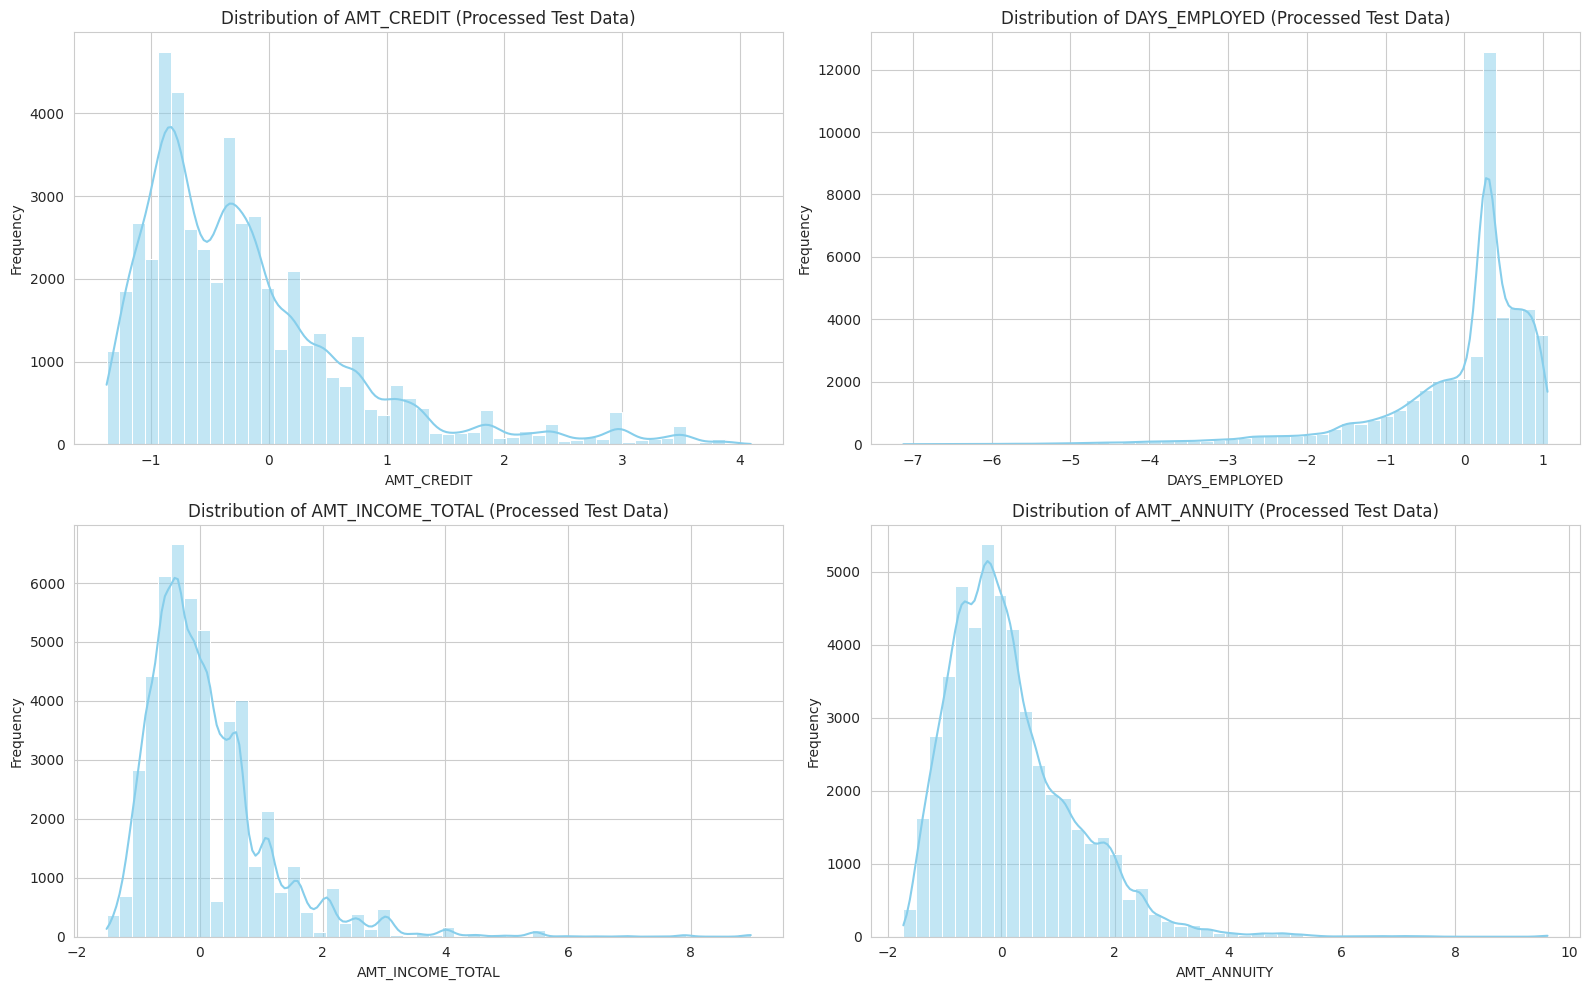

Generating count plots for one-hot encoded categorical features...


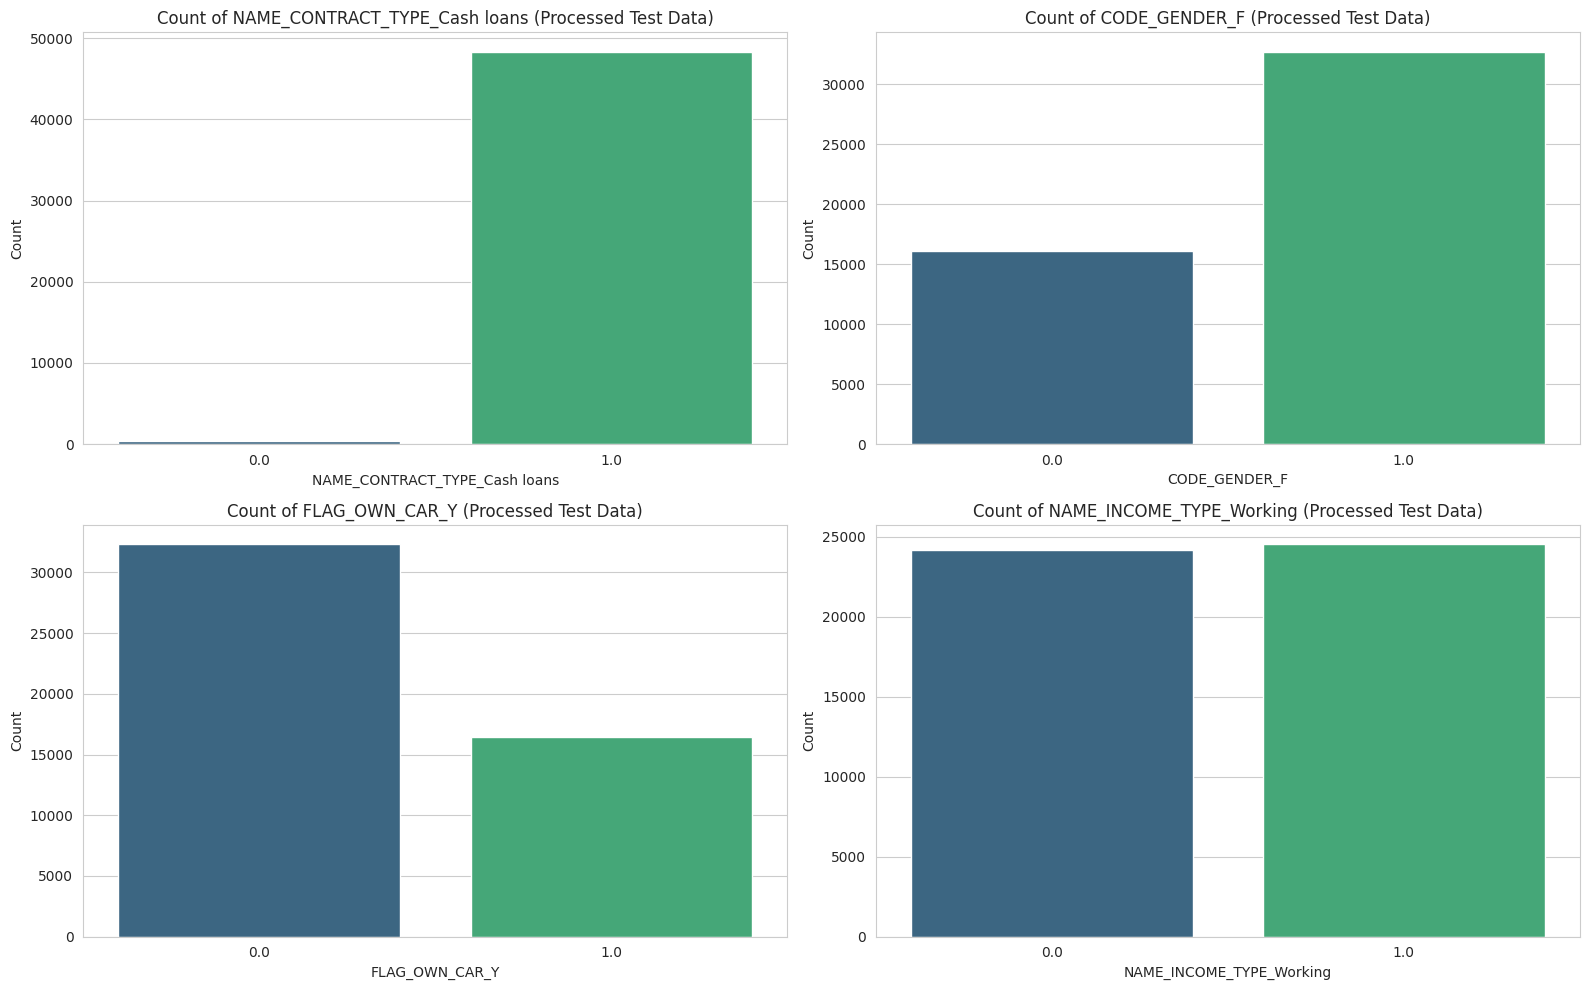

Feature visualization for test data complete.


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Visualizing Key Features in Processed Test Data ---")

# Set plot style
sns.set_style("whitegrid")

# 1. Histograms for selected numerical features

# Ensure these columns exist in the processed DataFrame
# The numerical_cols list was defined during training data preprocessing and is in the kernel state
# We will use some of the original numerical columns that are now scaled in X_test_processed_df
numerical_features_to_plot = ['AMT_CREDIT', 'DAYS_EMPLOYED', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY']

print("Generating histograms for numerical features...")
plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical_features_to_plot):
    if col in X_test_processed_df.columns:
        plt.subplot(2, 2, i + 1)
        sns.histplot(X_test_processed_df[col], kde=True, bins=50, color='skyblue')
        plt.title(f'Distribution of {col} (Processed Test Data)')
        plt.xlabel(col)
        plt.ylabel('Frequency')
    else:
        print(f"Warning: Numerical feature '{col}' not found in X_test_processed_df.")
plt.tight_layout()
plt.show()

# 2. Count plots for selected one-hot encoded categorical features

# The categorical_cols list was defined during training data preprocessing and is in the kernel state
# We need to select the one-hot encoded versions, which are now part of new_column_names
categorical_features_to_plot = ['NAME_CONTRACT_TYPE_Cash loans', 'CODE_GENDER_F', 'FLAG_OWN_CAR_Y', 'NAME_INCOME_TYPE_Working']

print("Generating count plots for one-hot encoded categorical features...")
plt.figure(figsize=(16, 10))
for i, col in enumerate(categorical_features_to_plot):
    if col in X_test_processed_df.columns:
        plt.subplot(2, 2, i + 1)
        # For one-hot encoded features, a countplot or barplot of value counts is appropriate
        sns.countplot(x=X_test_processed_df[col], hue=X_test_processed_df[col], palette='viridis', legend=False)
        plt.title(f'Count of {col} (Processed Test Data)')
        plt.xlabel(col)
        plt.ylabel('Count')
    else:
        print(f"Warning: Categorical feature '{col}' not found in X_test_processed_df.")
plt.tight_layout()
plt.show()

print("Feature visualization for test data complete.")

## Preprocess application_test.csv

### Subtask:
Apply the same cleaning, missing value imputation (using medians/modes from `application_train.csv`), outlier handling, and feature engineering steps to `application_test.csv` as were applied to `application_train.csv`. This ensures consistency between the training and testing datasets.


# Task
Apply the fitted preprocessor (OneHotEncoder and StandardScaler) from the training data to `df_test_cleaned` to transform it into `X_test_processed`.

## Apply Encoding and Scaling to Test Data

### Subtask:
Apply the fitted preprocessor (OneHotEncoder and StandardScaler) from the training data to `df_test_cleaned` to transform it into `X_test_processed`.


## Visualize Key Features in Test Data

### Subtask:
Generate visualizations (e.g., histograms for numerical features, count plots for categorical features) for a selection of key features in the processed `df_test_cleaned` or `X_test_processed` to understand their distributions and compare them with training data distributions if necessary.


## Final Task

### Subtask:
Provide a summary of the data preparation steps applied to the test data and the insights gained from the visualizations.


## Summary:

### Q&A
The data preparation steps involved applying a pre-fitted `preprocessor` (OneHotEncoder and StandardScaler) to the `df_test_cleaned` DataFrame to create `X_test_processed_df`. This process included extracting `SK_ID_CURR` before transformation and re-inserting it afterward to maintain its presence.

Insights from visualizations showed the distributions of selected numerical features (e.g., `AMT_CREDIT`, `DAYS_EMPLOYED`, `AMT_INCOME_TOTAL`, `AMT_ANNUITY`) via histograms, and the counts of selected one-hot encoded categorical features (e.g., `NAME_CONTRACT_TYPE_Cash loans`, `CODE_GENDER_F`, `FLAG_OWN_CAR_Y`, `NAME_INCOME_TYPE_Working`) via count plots. These visualizations confirmed the successful application of scaling and encoding, allowing for a preliminary understanding of the transformed feature distributions in the test data.

### Data Analysis Key Findings
*   **Test Data Preprocessing**: The `df_test_cleaned` was successfully transformed into `X_test_processed_df` using a pre-fitted `preprocessor` that applied OneHotEncoder and StandardScaler.
*   **Feature Consistency**: The `X_test` used for transformation included 107 features (numerical and categorical), aligning with the features the `preprocessor` was trained on.
*   **Dimensionality Change**: The final `X_test_processed_df` resulted in a shape of (48744, 229), an increase from the initial 107 features plus `SK_ID_CURR`, due to one-hot encoding.
*   **`SK_ID_CURR` Handling**: The `SK_ID_CURR` column was correctly separated from `df_test_cleaned` before transformation and re-inserted as the first column in `X_test_processed_df`.
*   **Visualization Confirmation**: Visualizations (histograms and count plots) were successfully generated for key processed features, confirming that numerical features were scaled and categorical features were one-hot encoded as expected.
*   **Seaborn Warning Resolution**: A `FutureWarning` during `sns.countplot` generation was identified and resolved by explicitly setting the `hue` parameter and `legend=False`.

### Insights or Next Steps
*   The test dataset is now fully preprocessed and aligned in structure and scaling with the training data, making it ready for model prediction or evaluation.
*   Comparing the distributions of key features in the processed test data with those of the training data could provide insights into potential data drift or consistency issues between the datasets.
